In [1]:
import ast
import os
import pandas as pd

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_data = f'{base_folder}/figure_data'
os.makedirs(figure_data, exist_ok=True)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

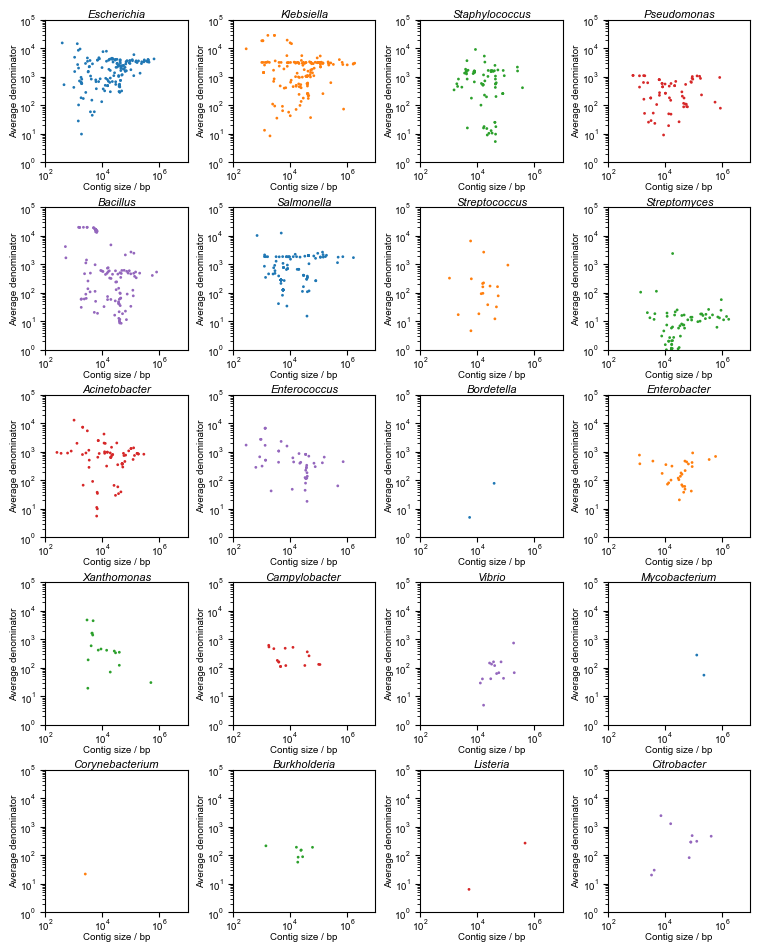

In [3]:
single_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

def scatter_figure(ax, deno_data, color):
    x = deno_data["size"]
    y = deno_data["average_denominator"]
    
    ax.scatter(x, y, c=color, alpha=1, edgecolors='none', s=4)
    ax.set_xlabel("Contig size / bp", labelpad=0)
    ax.set_ylabel("Average denominator", labelpad=0)
    ax.set_title(genus_name, fontproperties=title_font, pad=1)

    ax.set_xlim(1e2, 1e7)
    ax.set_ylim(1e0, 1e5)
    
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.tick_params(axis='x', pad=0)

fig = plt.figure(figsize=(7.5, 7.5))
gap = 0.06
split_size = 1/4
length = split_size - gap

i = 0
for genus_name in keep_genus:
    target_folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    try:
        deno_data = pd.read_csv(f'{target_folder}/intermediate_replicon_denominator_statistics.csv')
        replicon_data = pd.read_csv(f'{target_folder}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
        replicon_data.rename(columns={'accession': 'contig'}, inplace=True)
        deno_data = pd.merge(deno_data, replicon_data[['contig', 'size']])
    except:
        continue
        
    ax = fig.add_axes([gap+split_size*(i%4), 1-length-split_size*int(i/4), length, length])
    scatter_figure(ax, deno_data, single_colors[i%5])
    i+=1

figure_fold = '/active-data/analysis_results/chr_pla/genus/figures/scatter_plot'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig("S_intermediate_replicon_denominator.svg", bbox_inches="tight", transparent=True)
plt.savefig("S_intermediate_replicon_denominator.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()